# The k-Space Painters: all the figures

Every interactive figure of the book is computed here. Each cell is tagged with
`#| label: ...`, and the chapters embed its output with `:::{figure} #label`.
The shared simulation (the flower, the Fourier transform, the coils, SENSE and
GRAPPA) lives in `painters.py`, next to this notebook.

Run the whole notebook top to bottom and **save it with its outputs**: the book
shows the saved outputs, so a plain `myst start` displays every figure.

In [27]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import painters as P

# interactive figure for the web + PNG snapshot for the PDF (when kaleido works)
P.setup_plotly()

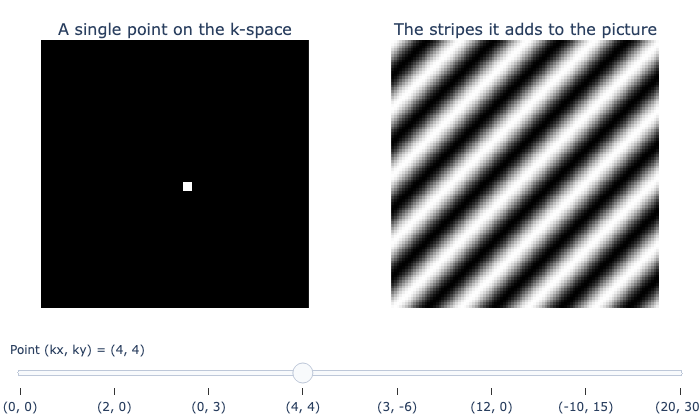

In [49]:
#| label: figWaves
n = P.N
y, x = np.mgrid[0:n, 0:n]
points = [(0, 0), (0, 2), (3, 0), (4, 4), (-6, 3), (0, 12), (15, -10), (30, 20)]
frames = []
for ky, kx in points:
    canvas = np.zeros((n, n))
    cy, cx = n // 2 + ky, n // 2 + kx
    canvas[max(cy - 1, 0):cy + 2, max(cx - 1, 0):cx + 2] = 1
    wave = np.cos(2 * np.pi * (kx * x + ky * y) / n)
    frames.append([P.to_u8(canvas), P.to_u8((wave + 1) / 2, 1)])
fig = P.slider_panels(frames, [f"({kx}, {ky})" for ky, kx in points],
                      ["A single point on the k-space", "The stripes it adds to the picture"],
                      default=3, prefix="Point (kx, ky) = ")
fig

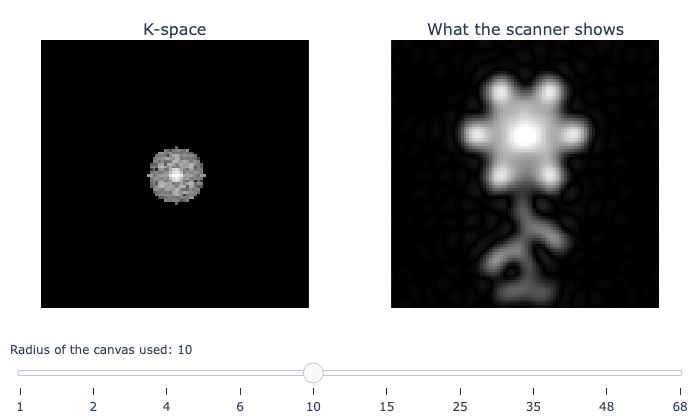

In [48]:
#| label: figCentreOut
img = P.flower()
k = P.fft2c(img)
kmax = np.log1p(np.abs(k)).max()
r = np.hypot(*np.mgrid[-n // 2:n // 2, -n // 2:n // 2])
radii = [1, 2, 4, 6, 10, 15, 25, 35, 48, 68]
frames = []
for R in radii:
    kk = np.where(r <= R, k, 0)
    frames.append([P.kspace_u8(kk, kmax), P.to_u8(P.ifft2c(kk), img.max())])
fig = P.slider_panels(frames, radii, ["K-space", "What the scanner shows"],
                      default=4, prefix="Radius of the canvas used: ")
fig

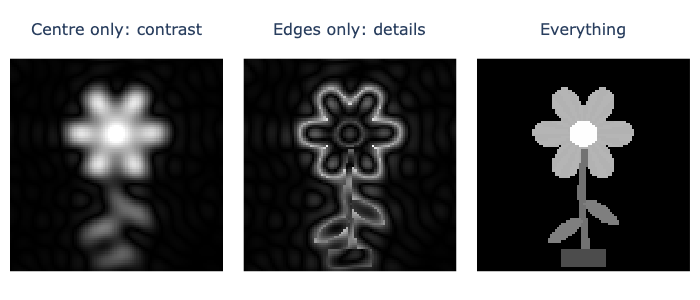

In [47]:
#| label: figCentreEdges
centre = np.where(r <= 8, k, 0)
edges = np.where(r > 8, k, 0)
fig = P.static_panels([P.to_u8(P.ifft2c(centre), img.max()), P.to_u8(P.ifft2c(edges)), P.to_u8(img)],
                      ["Centre only: contrast", "Edges only: details", "Everything"], height=300)
fig

## Greta walks back every time

Figures of `01-gre.md`.

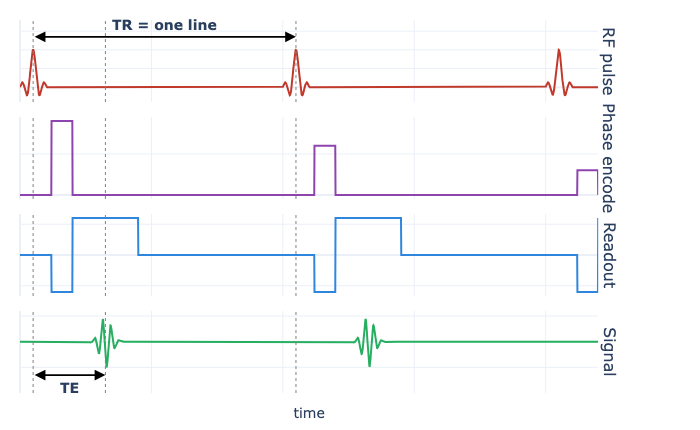

In [29]:
#| label: figGreTiming

t = np.linspace(0, 2.2, 2200)          # two repetitions, arbitrary units (1 = one TR)
def box(t0, t1, amp=1.0):
    return np.where((t >= t0) & (t < t1), amp, 0.0)

rf = sum(np.sinc((t - (k + 0.05)) * 60) * ((t > k) & (t < k + 0.1)) for k in (0, 1, 2))
pe = sum(box(k + 0.12, k + 0.2, a) for k, a in ((0, 0.9), (1, 0.6), (2, 0.3)))
ro = sum(box(k + 0.12, k + 0.2, -0.6) + box(k + 0.2, k + 0.45, 0.6) for k in (0, 1, 2))
sig = sum(np.exp(-((t - (k + 0.325)) / 0.03) ** 2) * np.cos(200 * (t - k)) for k in (0, 1, 2))

t_rf, t_echo = 0.05, 0.325             # centre of the 1st RF pulse and of the 1st echo

fig = make_subplots(rows=4, cols=1, shared_xaxes=True, vertical_spacing=0.04,
                    row_titles=["RF pulse", "Phase encode", "Readout", "Signal"])
for i, (y, c) in enumerate([(rf, "#C0392B"), (pe, "#8E44AD"), (ro, "#2E86DE"), (sig, "#27AE60")]):
    fig.add_trace(go.Scatter(x=t, y=y, line=dict(color=c, width=2), hoverinfo="skip"), row=i + 1, col=1)

# dotted guides through all rows: the two RF pulses and the first echo
for x in (t_rf, t_rf + 1, t_echo):
    fig.add_vline(x=x, line=dict(color="gray", width=1, dash="dot"), row="all", col=1)

def double_arrow(x0, x1, y, xref, yref, label, above=True):
    """A <-> arrow from x0 to x1 at height y, with its label above (or below) it."""
    fig.add_annotation(x=x1, y=y, ax=x0, ay=y, xref=xref, yref=yref, axref=xref, ayref=yref,
                       text="", showarrow=True, arrowhead=2, arrowside="end+start",
                       arrowsize=1.2, arrowwidth=1.8, arrowcolor="black")
    fig.add_annotation(x=(x0 + x1) / 2, y=y, xref=xref, yref=yref, text=f"<b>{label}</b>",
                       showarrow=False, yshift=12 if above else -12, font=dict(size=14))

# TR: from one RF pulse to the next (top row)
double_arrow(t_rf, t_rf + 1, 1.35, "x", "y", "TR = one line")
# TE: from the RF pulse to the centre of the echo (bottom row)
double_arrow(t_rf, t_echo, -1.3, "x4", "y4", "TE", above=False)

fig.update_yaxes(showticklabels=False, zeroline=True)
fig.update_yaxes(range=[-0.4, 1.8], row=1, col=1)      # room for the TR arrow
fig.update_yaxes(range=[-2.0, 1.2], row=4, col=1)      # room for the TE arrow
fig.update_xaxes(title_text="time", row=4, col=1, showticklabels=False)
fig.update_layout(height=430, showlegend=False, template="plotly_white",
                  margin=dict(l=20, r=90, t=20, b=30))
fig

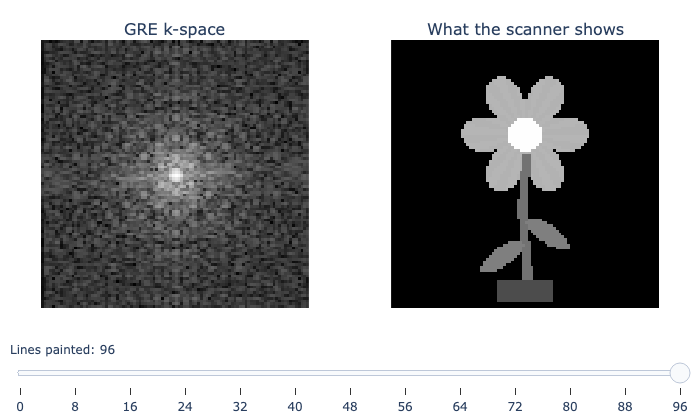

In [30]:
#| label: figGreFill
img = P.flower()
k = P.fft2c(img)
kmax = np.log1p(np.abs(k)).max()
steps = list(range(0, P.N + 1, 8))
frames = []
for n in steps:
    kk = np.zeros_like(k)
    kk[:n] = k[:n]
    frames.append([P.kspace_u8(kk, kmax), P.to_u8(P.ifft2c(kk), np.abs(img).max())])
fig = P.slider_panels(frames, steps, ["GRE k-space", "What the scanner shows"],
                      default=len(steps) - 1, prefix="Lines painted: ")
fig

## Ziggy carries all the paint

Figures of `03-epi.md`.

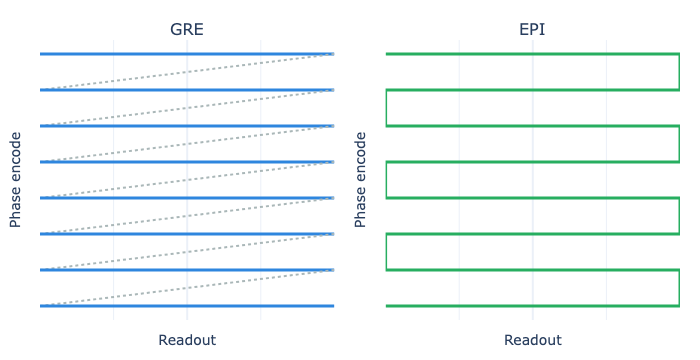

In [31]:
#| label: figEpiTrajectory
n = 8
fig = make_subplots(rows=1, cols=2, subplot_titles=["GRE", "EPI"],
                    horizontal_spacing=0.08)
for r in range(n):                                        # GRE: every line left to right
    fig.add_trace(go.Scatter(x=[-1, 1], y=[r, r], mode="lines", line=dict(color="#2E86DE", width=3)), 1, 1)
    if r < n - 1:
        fig.add_trace(go.Scatter(x=[1, -1], y=[r, r + 1], mode="lines",
                                 line=dict(color="#AAB7B8", dash="dot")), 1, 1)
xs, ys = [], []
for r in range(n):                                        # EPI: zigzag
    a, b = (-1, 1) if r % 2 == 0 else (1, -1)
    xs += [a, b]
    ys += [r, r]
fig.add_trace(go.Scatter(x=xs, y=ys, mode="lines", line=dict(color="#27AE60", width=3)), 1, 2)
fig.update_yaxes(autorange="reversed", title_text="Phase encode", showticklabels=False)
fig.update_xaxes(title_text="Readout", showticklabels=False)
fig.update_layout(showlegend=False, template="plotly_white", height=360,
                  margin=dict(l=40, r=20, t=40, b=40))
fig

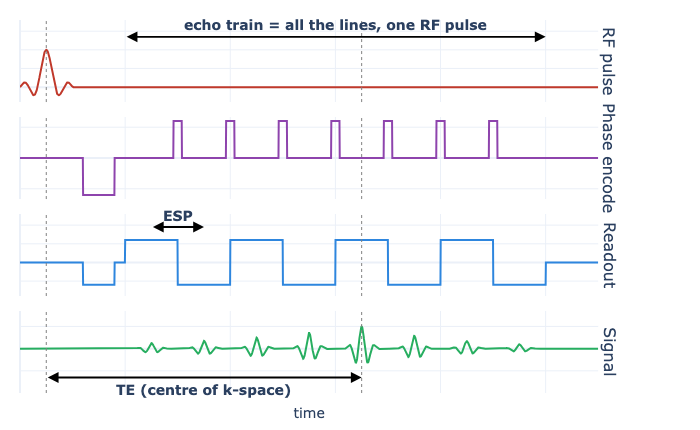

In [32]:
#| label: figEpiTiming
t = np.linspace(0, 1.1, 2200)          # one excitation, arbitrary time units
def box(t0, t1, amp=1.0):
    return np.where((t >= t0) & (t < t1), amp, 0.0)

n_lines = 8                            # 8 lines drawn here (96 in the simulation)
t_rf = 0.05                            # centre of the single RF pulse
t0, dur = 0.2, 0.1                     # start of the first readout lobe, length of one line
t_echo = [t0 + dur * (j + 0.5) for j in range(n_lines)]   # centre of each echo
j_centre = n_lines // 2                # the line through the centre of k-space
T2s = 1.0                              # T2*, same time units

rf = np.sinc((t - t_rf) * 60) * ((t > 0) & (t < 0.1))
# phase encode: one negative prephaser (go to the top line), then a small blip between lines
pe = box(0.12, 0.18, -0.6) + sum(box(t0 + dur * (j + 1) - 0.008, t0 + dur * (j + 1) + 0.008, 0.6)
                                 for j in range(n_lines - 1))
# readout: half-size prephaser, then lobes alternating left -> right, right -> left
ro = box(0.12, 0.18, -0.6) + sum(box(t0 + dur * j, t0 + dur * (j + 1), 0.6 if j % 2 == 0 else -0.6)
                                 for j in range(n_lines))
# signal: one echo per line, strongest at the centre of k-space, fading with T2*
decay = np.exp(-(t - t_echo[j_centre]) / T2s)   # = 1 at the centre echo
sig = sum(np.exp(-0.45 * abs(j - j_centre)) * np.exp(-((t - te) / 0.018) ** 2) * np.cos(250 * (t - te))
          for j, te in enumerate(t_echo)) * decay

fig = make_subplots(rows=4, cols=1, shared_xaxes=True, vertical_spacing=0.04,
                    row_titles=["RF pulse", "Phase encode", "Readout", "Signal"])
for i, (y, c) in enumerate([(rf, "#C0392B"), (pe, "#8E44AD"), (ro, "#2E86DE"), (sig, "#27AE60")]):
    fig.add_trace(go.Scatter(x=t, y=y, line=dict(color=c, width=2), hoverinfo="skip"), row=i + 1, col=1)


# dotted guides through all rows: the RF pulse and the centre echo
for x in (t_rf, t_echo[j_centre]):
    fig.add_vline(x=x, line=dict(color="gray", width=1, dash="dot"), row="all", col=1)

def double_arrow(x0, x1, y, xref, yref, label, above=True):
    """A <-> arrow from x0 to x1 at height y, with its label above (or below) it."""
    fig.add_annotation(x=x1, y=y, ax=x0, ay=y, xref=xref, yref=yref, axref=xref, ayref=yref,
                       text="", showarrow=True, arrowhead=2, arrowside="end+start",
                       arrowsize=1.2, arrowwidth=1.8, arrowcolor="black")
    fig.add_annotation(x=(x0 + x1) / 2, y=y, xref=xref, yref=yref, text=f"<b>{label}</b>",
                       showarrow=False, yshift=12 if above else -12, font=dict(size=14))

# the echo train: every line after a single RF pulse (top row)
double_arrow(t0, t0 + dur * n_lines, 1.35, "x", "y", "echo train = all the lines, one RF pulse")
# echo spacing: time between two lines (readout row)
double_arrow(t_echo[0], t_echo[1], 0.95, "x3", "y3", "ESP")
# TE: from the RF pulse to the echo of the central line (bottom row)
double_arrow(t_rf, t_echo[j_centre], -1.3, "x4", "y4", "TE (centre of k-space)", above=False)

fig.update_yaxes(showticklabels=False, zeroline=True)
fig.update_yaxes(range=[-0.4, 1.8], row=1, col=1)      # room for the echo-train arrow
fig.update_yaxes(range=[-0.9, 1.3], row=3, col=1)      # room for the ESP arrow
fig.update_yaxes(range=[-2.0, 1.7], row=4, col=1)      # room for the TE arrow
fig.update_xaxes(title_text="time", row=4, col=1, showticklabels=False)
fig.update_layout(height=430, showlegend=False, template="plotly_white",
                  margin=dict(l=20, r=90, t=20, b=30))
fig

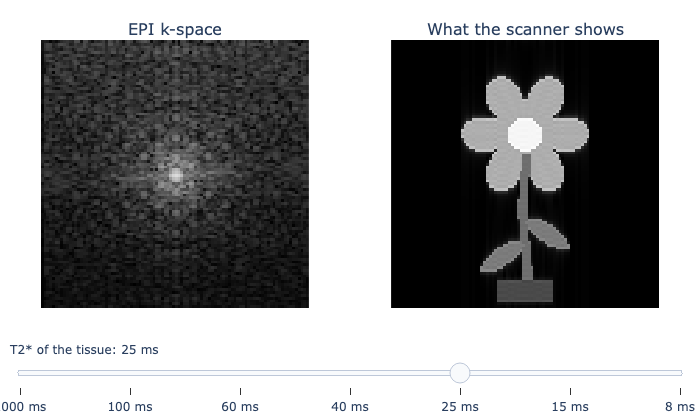

In [33]:
#| label: figEpiBlur
img = P.flower()
k = P.fft2c(img)
esp = 0.5                                   # ms per line (echo spacing)
t = np.arange(P.N) * esp                    # time at which each line is painted
t = t - t[P.N // 2]                         # the centre line is the echo time
T2s = [1000, 100, 60, 40, 25, 15, 8]
frames = []
kmax = np.log1p(np.abs(k)).max()
for T2 in T2s:
    kk = k * np.exp(-(t - t[0]) / T2)[:, None]   # the paint fades from the first line on
    frames.append([P.kspace_u8(kk, kmax), P.to_u8(P.ifft2c(kk))])
fig = P.slider_panels(frames, [f"{v} ms" for v in T2s], ["EPI k-space", "What the scanner shows"],
                      default=4, prefix="T2* of the tissue: ")
fig

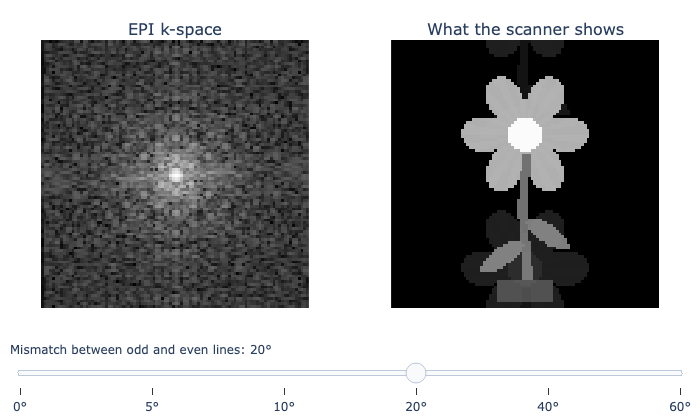

In [34]:
#| label: figEpiGhost
errs = [0, 5, 10, 20, 40, 60]
frames = []
for e in errs:
    kk = k.copy()
    kk[1::2] *= np.exp(1j * np.deg2rad(e))
    frames.append([P.kspace_u8(kk, kmax), P.to_u8(P.ifft2c(kk), img.max())])
fig = P.slider_panels(frames, [f"{e}°" for e in errs], ["EPI k-space", "What the scanner shows"],
                      default=3, prefix="Mismatch between odd and even lines: ")
fig

## Skip skips lines

Figures of `04-undersampling.md`.

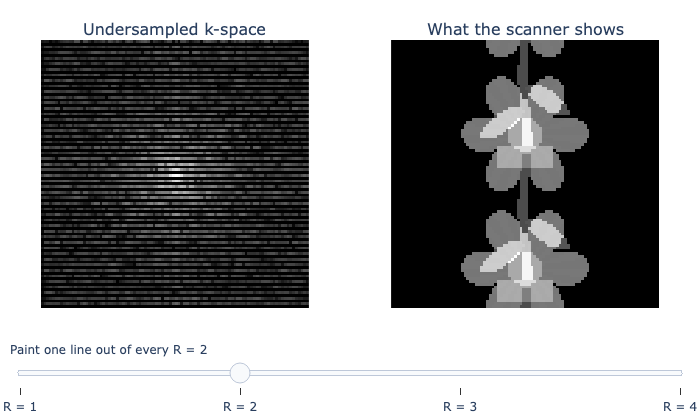

In [35]:
#| label: figAliasing
img = P.flower()
k = P.fft2c(img)
kmax = np.log1p(np.abs(k)).max()
Rs = [1, 2, 3, 4]
frames = []
for R in Rs:
    ku, _ = P.undersample(k, R)
    frames.append([P.kspace_u8(ku, kmax), P.to_u8(P.ifft2c(ku))])
fig = P.slider_panels(frames, [f"R = {R}" for R in Rs], ["Undersampled k-space", "What the scanner shows"],
                      default=1, prefix="Paint one line out of every ")
fig

## The Sense Quartet

Figures of `05-sense.md`.

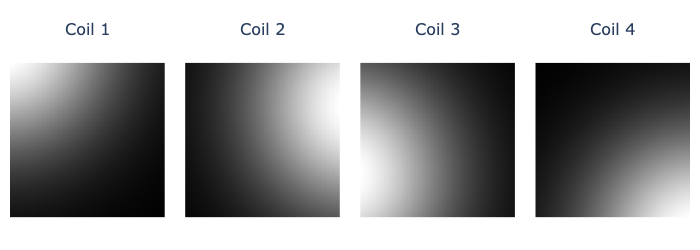

In [36]:
#| label: figCoilMaps
img = P.flower()
maps = P.coil_maps()
coil_imgs = maps * img
fig = P.static_panels([P.to_u8(m) for m in maps], [f"Coil {i + 1}" for i in range(4)], height=250)
fig

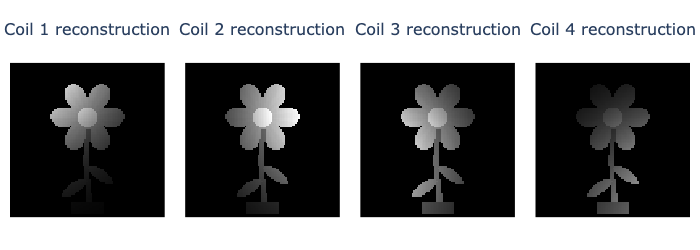

In [37]:
#| label: figCoilImages
fig = P.static_panels([P.to_u8(c, np.abs(coil_imgs).max()) for c in coil_imgs],
                      [f"Coil {i + 1} reconstruction" for i in range(4)], height=250)
fig

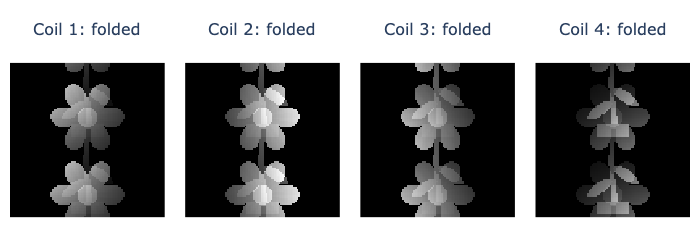

In [38]:
#| label: figCoilFolded
img = P.flower()
maps = P.coil_maps()
R = 2                                          # the quartet paints only 1 line in 4

k_coils = P.fft2c(maps * img)                  # each coil's complete k-space
k_skip, _ = P.undersample(k_coils, R)          # everyone skips the same lines
folded = R * P.ifft2c(k_skip)                  # what the scanner shows for each coil

vmax = np.abs(folded).max()                    # same brightness scale for the four coils
fig = P.static_panels([P.to_u8(f, vmax) for f in folded],
                      [f"Coil {i + 1}: folded" for i in range(len(folded))], height=250)
fig

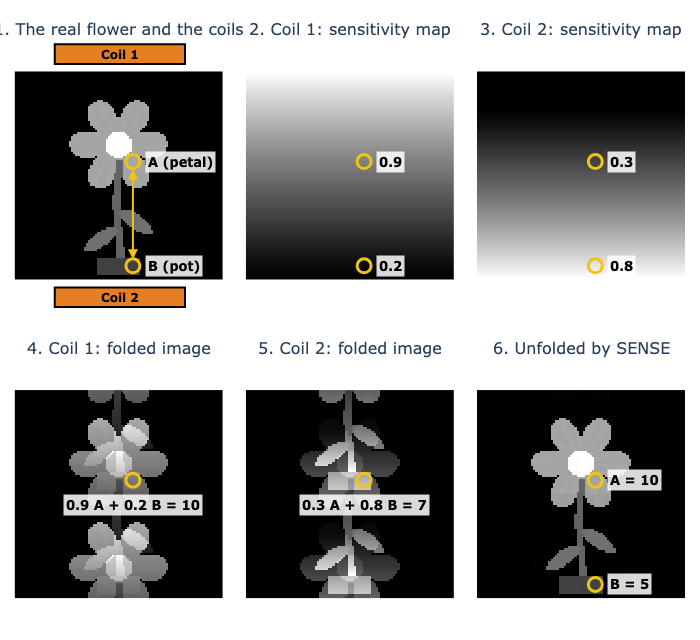

In [39]:
#| label: figSenseExample
# The worked example of the chapter, drawn on the real flower:
# two coils (coil 1 above the flower = Red, coil 2 below = Blue), R = 2, one folded pixel.
img = P.flower()
n = P.N
rowA, rowB, col = 41, 89, 54            # A on a petal, B on the pot, exactly n/2 rows lower

# Two simple sensitivity maps that give exactly the numbers of the example at A and B
rows = np.arange(n)[:, None] * np.ones((1, n))
frac = (rows - rowA) / (rowB - rowA)    # 0 at A, 1 at B
S_coil1 = np.clip(0.9 + (0.2 - 0.9) * frac, 0.05, None)   # no upper cap: smooth all the way up
S_coil2 = np.clip(0.3 + (0.8 - 0.3) * frac, 0.05, None)

def folded(S):
    k, _ = P.undersample(P.fft2c(S * img), 2)
    return 2 * np.abs(P.ifft2c(k))

# SENSE with these two coils: solve the two equations for every folded pixel
maps2 = np.array([S_coil1, S_coil2])
aliased = P.ifft2c(P.undersample(P.fft2c(maps2 * img), 2)[0])
unfolded = np.abs(P.sense(aliased, maps2, 2))

panels = [
    (img, "1. The real flower and the coils"),
    (S_coil1, "2. Coil 1: sensitivity map"),
    (S_coil2, "3. Coil 2: sensitivity map"),
    (folded(S_coil1), "4. Coil 1: folded image"),
    (folded(S_coil2), "5. Coil 2: folded image"),
    (unfolded, "6. Unfolded by SENSE"),
]
fig = make_subplots(rows=2, cols=3, subplot_titles=[p[1] for p in panels],
                    horizontal_spacing=0.02, vertical_spacing=0.08)
for i, (z, _) in enumerate(panels):
    r, c = i // 3 + 1, i % 3 + 1
    fig.add_trace(go.Heatmap(z=z, colorscale="gray", zmin=0, showscale=False, hoverinfo="skip"),
                  row=r, col=c)

# 1. the two receive coils, drawn above and below the flower
for y0, y1, label in ((-13, -4, "Coil 1"), (n + 3, n + 12, "Coil 2")):
    fig.add_shape(type="rect", x0=18, x1=n - 18, y0=y0, y1=y1, xref="x", yref="y",
                  fillcolor="#E67E22", line=dict(color="black", width=2))
    fig.add_annotation(x=n / 2, y=(y0 + y1) / 2, xref="x", yref="y", text=f"<b>{label}</b>",
                       showarrow=False, font=dict(size=12, color="black"))

def mark(i, row, text, color="#F1C40F", pos="right"):
    """Circle a pixel of panel i and write a label next to it, on a white tag."""
    ax = "" if i == 0 else str(i + 1)
    fig.add_trace(go.Scatter(x=[col], y=[row], mode="markers", hoverinfo="skip",
                             marker=dict(size=14, color="rgba(0,0,0,0)", line=dict(color=color, width=3)),
                             xaxis=f"x{ax}", yaxis=f"y{ax}"))
    shift = dict(right=dict(xshift=12, xanchor="left"), below=dict(yshift=-14, yanchor="top"))[pos]
    fig.add_annotation(x=col, y=row, xref=f"x{ax}", yref=f"y{ax}", text=f"<b>{text}</b>",
                       showarrow=False, bgcolor="rgba(255,255,255,0.85)", borderpad=2,
                       font=dict(size=13, color="black"), **shift)

# 1. the two points, half a picture apart
mark(0, rowA, "A (petal)", "#F1C40F")
mark(0, rowB, "B (pot)", "#F1C40F")
fig.add_annotation(x=col, y=rowB - 3, ax=col, ay=rowA + 3, xref="x", yref="y", axref="x", ayref="y",
                   showarrow=True, arrowhead=2, arrowside="end+start", arrowcolor="#F1C40F",
                   arrowwidth=2, text="")
# 2-3. how well each coil sees A and B
mark(1, rowA, "0.9"); mark(1, rowB, "0.2")
mark(2, rowA, "0.3"); mark(2, rowB, "0.8")
# 4-5. A and B land on the same folded pixel
mark(3, rowA, "0.9 A + 0.2 B = 10", pos="below")
mark(4, rowA, "0.3 A + 0.8 B = 7", pos="below")
# 6. each value back in its true place
mark(5, rowA, "A = 10", "#F1C40F"); mark(5, rowB, "B = 5", "#F1C40F")

for i in range(6):
    ax = "" if i == 0 else str(i + 1)
    # same extended range in every panel, so the coils fit and all images keep the same size
    fig.update_layout(**{f"xaxis{ax}": dict(visible=False, range=[-0.5, n - 0.5],
                                            scaleanchor=f"y{ax}", constrain="domain"),
                         f"yaxis{ax}": dict(visible=False, range=[n + 14, -15], constrain="domain")})
fig.update_layout(height=640, showlegend=False, template="plotly_white",
                  margin=dict(l=10, r=10, t=40, b=10))
fig

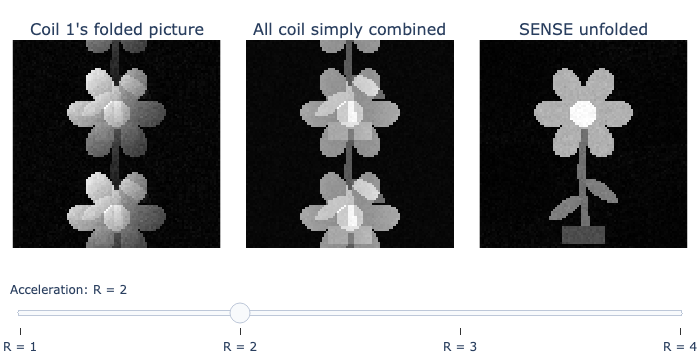

In [40]:
#| label: figSense
rng = np.random.default_rng(0)
k_coils = P.fft2c(coil_imgs)
sigma = 0.015 * np.abs(k_coils).max() / np.sqrt(P.N)
k_coils = k_coils + sigma * (rng.standard_normal(k_coils.shape) + 1j * rng.standard_normal(k_coils.shape))

Rs = [1, 2, 3, 4]
ref = P.rss(P.ifft2c(k_coils))
vmax = ref.max()
frames = []
for R in Rs:
    ku, _ = P.undersample(k_coils, R)
    aliased = P.ifft2c(ku)
    rec = P.sense(aliased, maps, R)
    frames.append([P.to_u8(aliased[0]), P.to_u8(P.rss(aliased)), P.to_u8(rec, img.max())])
fig = P.slider_panels(frames, [f"R = {R}" for R in Rs],
                      ["Coil 1's folded picture", "All coil simply combined", "SENSE unfolded"],
                      default=1, prefix="Acceleration: ", height=360)
fig

## Grappa learns to guess

Figures of `06-grappa.md`.

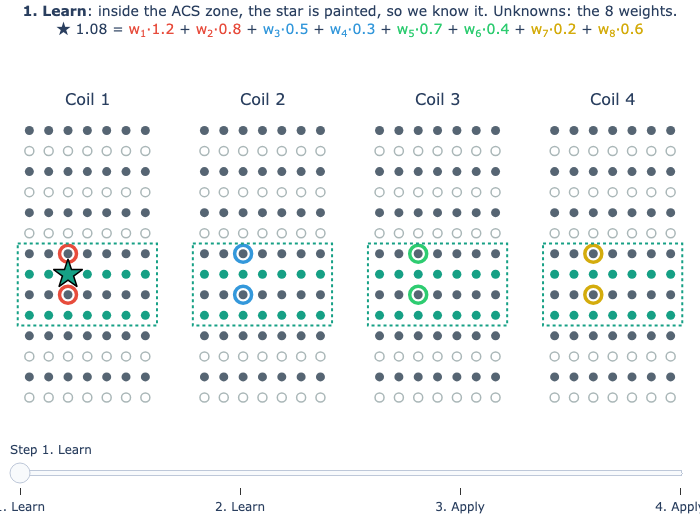

In [50]:
#| label: figGrappaKernelbis
# GRAPPA step by step on a schematic k-space of the four coils (R = 2).
# To keep the equations readable, the kernel uses only the painted point just above
# and just below the target, in each coil: 8 source points, so 8 weights w1 ... w8.
nrow, ncol, R = 14, 7, 2
acs = [6, 7, 8, 9]                                  # the practice zone (ACS lines)
coil_colours = ["#E74C3C", "#3498DB", "#2ECC71", "#D4AC0D"]

# Made-up weights and point values, chosen only to illustrate (real ones are complex)
w = np.array([0.5, 0.3, 0.2, -0.1, 0.1, 0.2, -0.2, 0.1])
steps = [  # (label, target row, target column, values of the 8 source points)
    ("1. Learn", 7, 2, [1.2, 0.8, 0.5, 0.3, 0.7, 0.4, 0.2, 0.6]),
    ("2. Learn", 9, 4, [0.9, 1.1, 0.4, 0.6, 0.3, 0.5, 0.7, 0.2]),
    ("3. Apply", 3, 3, [1.4, 1.0, 0.6, 0.2, 0.5, 0.8, 0.3, 0.4]),
    ("4. Apply", 11, 5, [0.6, 0.4, 0.3, 0.5, 0.9, 0.2, 0.1, 0.7]),
]

def equation(label, vals):
    """The equation written above the figure, each term in the colour of its coil."""
    target = float(np.dot(w, vals))
    learn = label.endswith("Learn")
    terms = []
    for i, v in enumerate(vals):
        if learn:
            sign, coef = ("" if i == 0 else "+ "), f"w<sub>{i + 1}</sub>"
        else:
            sign = ("− " if w[i] < 0 else ("" if i == 0 else "+ "))
            coef = f"{abs(w[i]):.1f}"
        terms.append(f"{sign}<span style='color:{coil_colours[i // 2]}'>{coef}·{v:.1f}</span>")
    rhs = " ".join(terms)
    if learn:
        head = (f"<b>{label}</b>: inside the ACS zone, the star is painted, so we know it. "
                f"Unknowns: the 8 weights.")
        return f"{head}<br>★ {target:.2f} = {rhs}"
    head = (f"<b>{label}</b>: outside, the star is missing. The weights are now known "
            f"(learned from thousands of equations like 1 and 2).")
    return f"{head}<br>★ = {rhs} = <b>{target:.2f}</b>"

fig = make_subplots(rows=1, cols=4, subplot_titles=[f"Coil {i + 1}" for i in range(4)],
                    horizontal_spacing=0.03)
rows, cols = np.mgrid[0:nrow, 0:ncol]
in_acs = np.isin(rows, acs)
painted = (rows % R == 0) | in_acs

def dots(mask, **marker):
    return go.Scatter(x=cols[mask], y=rows[mask], mode="markers", hoverinfo="skip", marker=marker)

n_static = 0
for p in range(4):                                  # the same grid in the four coils
    fig.add_trace(dots(painted & ~(in_acs & (rows % R != 0)), size=9, color="#566573"), 1, p + 1)
    fig.add_trace(dots(in_acs & (rows % R != 0), size=9, color="#16A085"), 1, p + 1)
    fig.add_trace(dots(~painted, size=9, color="white", line=dict(color="#AAB7B8", width=1.5)), 1, p + 1)
    fig.add_shape(type="rect", x0=-0.6, x1=ncol - 0.4, y0=acs[0] - 0.5, y1=acs[-1] + 0.5,
                  line=dict(color="#16A085", width=2, dash="dot"), row=1, col=p + 1)
    n_static += 3

for s, (label, tr, tc, vals) in enumerate(steps):
    for p in range(4):                              # source points: above and below, in every coil
        fig.add_trace(go.Scatter(x=[tc, tc], y=[tr - 1, tr + 1], mode="markers", hoverinfo="skip",
                                 visible=(s == 0),
                                 marker=dict(size=17, color="rgba(0,0,0,0)",
                                             line=dict(color=coil_colours[p], width=3.5))), 1, p + 1)
    fig.add_trace(go.Scatter(x=[tc], y=[tr], mode="markers", hoverinfo="skip", visible=(s == 0),
                             marker=dict(symbol="star", size=22,
                                         color="#16A085" if label.endswith("Learn") else "#C0392B",
                                         line=dict(color="black", width=1.5))), 1, 1)

per_step = 5                                        # 4 pairs of rings + 1 star
slider_steps = []
for s, (label, _, _, vals) in enumerate(steps):
    vis = [True] * n_static + [False] * (per_step * len(steps))
    vis[n_static + per_step * s: n_static + per_step * (s + 1)] = [True] * per_step
    slider_steps.append(dict(method="update", label=label,
                             args=[{"visible": vis}, {"title.text": equation(label, vals)}]))

fig.update_layout(title=dict(text=equation(*steps[0][::3]), x=0.5, xanchor="center",
                             y=0.97, yanchor="top", font=dict(size=14)),
                  sliders=[dict(active=0, steps=slider_steps, pad={"t": 20},
                                currentvalue={"prefix": "Step "})],
                  showlegend=False, template="plotly_white", height=520,
                  margin=dict(l=10, r=10, t=110, b=10))
for p in range(4):
    ax = "" if p == 0 else str(p + 1)
    fig.update_layout(**{f"xaxis{ax}": dict(visible=False, range=[-1, ncol]),
                         f"yaxis{ax}": dict(visible=False, range=[nrow, -1])})
fig

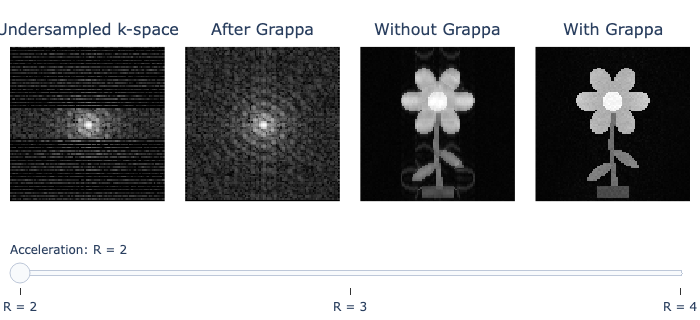

In [51]:
#| label: figGrappa
img = P.flower()
maps = P.coil_maps()
rng = np.random.default_rng(0)
k_coils = P.fft2c(maps * img)
sigma = 0.015 * np.abs(k_coils).max() / np.sqrt(P.N)
k_coils = k_coils + sigma * (rng.standard_normal(k_coils.shape) + 1j * rng.standard_normal(k_coils.shape))

NACS = 18
acs_rows = np.arange(P.N // 2 - NACS // 2, P.N // 2 + NACS // 2)
kmax = np.log1p(np.abs(k_coils[0])).max()
vmax = P.rss(P.ifft2c(k_coils)).max()
Rs = [2, 3, 4]
frames = []
for R in Rs:
    ku, mask = P.undersample(k_coils, R, acs=NACS)
    kg = P.grappa(ku, mask, acs_rows, R)
    frames.append([P.kspace_u8(ku[0], kmax), P.kspace_u8(kg[0], kmax),
                   P.to_u8(P.rss(P.ifft2c(ku)), vmax), P.to_u8(P.rss(P.ifft2c(kg)), vmax)])
fig = P.slider_panels(frames, [f"R = {R}" for R in Rs],
                      ["Undersampled k-space", "After Grappa", "Without Grappa", "With Grappa"],
                      default=0, prefix="Acceleration: ", height=320)
fig

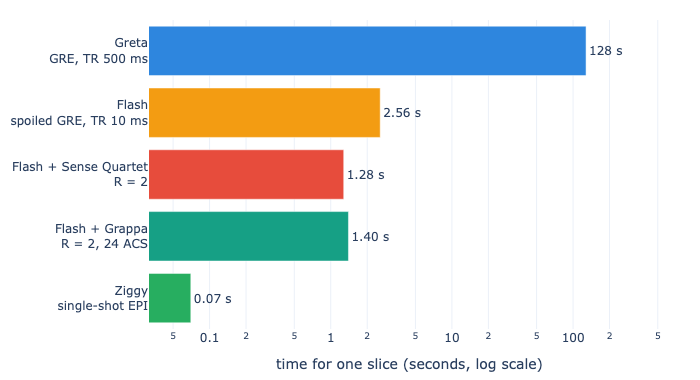

In [45]:
#| label: figRace
methods = ["Greta<br>GRE, TR 500 ms", "Flash<br>spoiled GRE, TR 10 ms", "Flash + Sense Quartet<br>R = 2",
           "Flash + Grappa<br>R = 2, 24 ACS", "Ziggy<br>single-shot EPI"]
times = [256 * 0.5, 256 * 0.010, 128 * 0.010, 140 * 0.010, 0.07]
colors = ["#2E86DE", "#F39C12", "#E74C3C", "#16A085", "#27AE60"]
fig = go.Figure(go.Bar(x=times, y=methods, orientation="h", marker_color=colors,
                       text=[f"{t:.2f} s" if t < 10 else f"{t:.0f} s" for t in times],
                       textposition="outside", hoverinfo="skip"))
fig.update_layout(xaxis=dict(type="log", title="time for one slice (seconds, log scale)", range=[-1.5, 2.8]),
                  yaxis=dict(autorange="reversed"), template="plotly_white", height=380,
                  margin=dict(l=10, r=30, t=20, b=50))
fig